## Предобработка данных


### Классная работа

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import resample

In [166]:
training_set = pd.read_csv('https://raw.githubusercontent.com/koroteevmv/ML_course/refs/heads/main/ML5.5%20EDA/data/titanic.csv')

In [167]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [168]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [169]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [170]:
training_set.describe(include=['O'])

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Dooley, Mr. Patrick",male,347082,G6,S
freq,1,577,7,4,644


#### Описание каждого признака

In [171]:
def custom_hist(training_set, title,  xlabel, ylabel='Количество', bins=None):
    figsize = (20,6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(training_set, int(training_set.max()) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

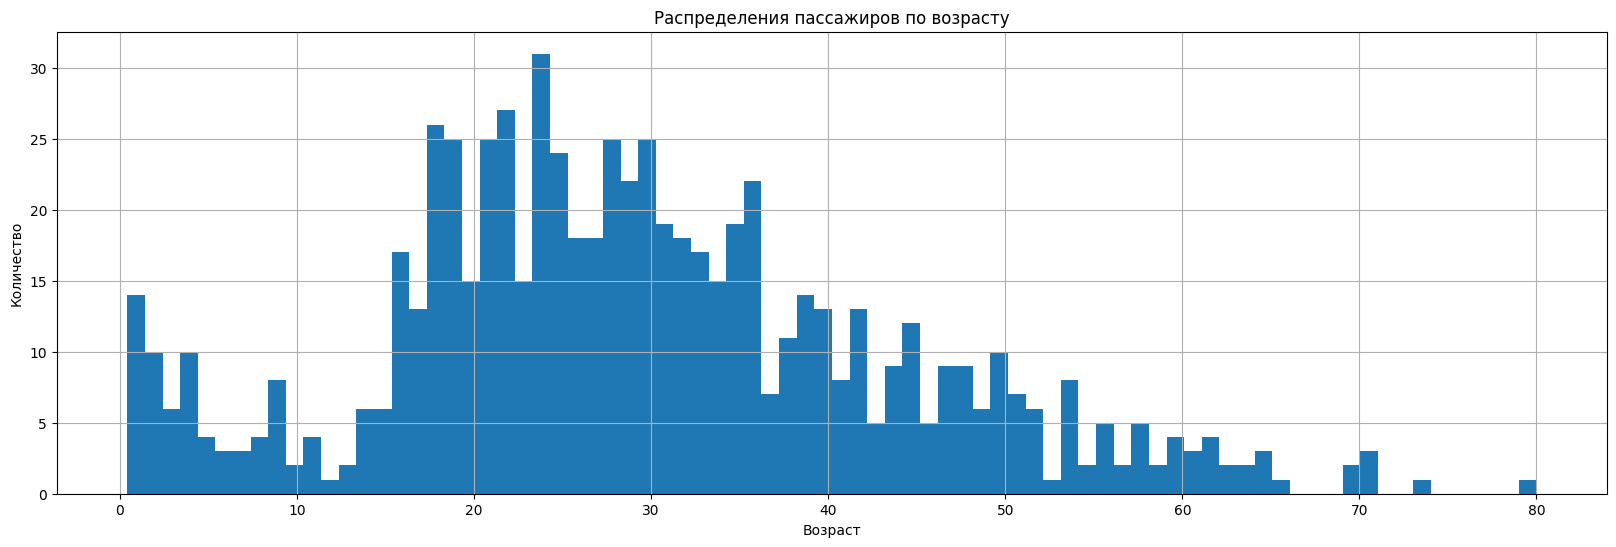

In [172]:
custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

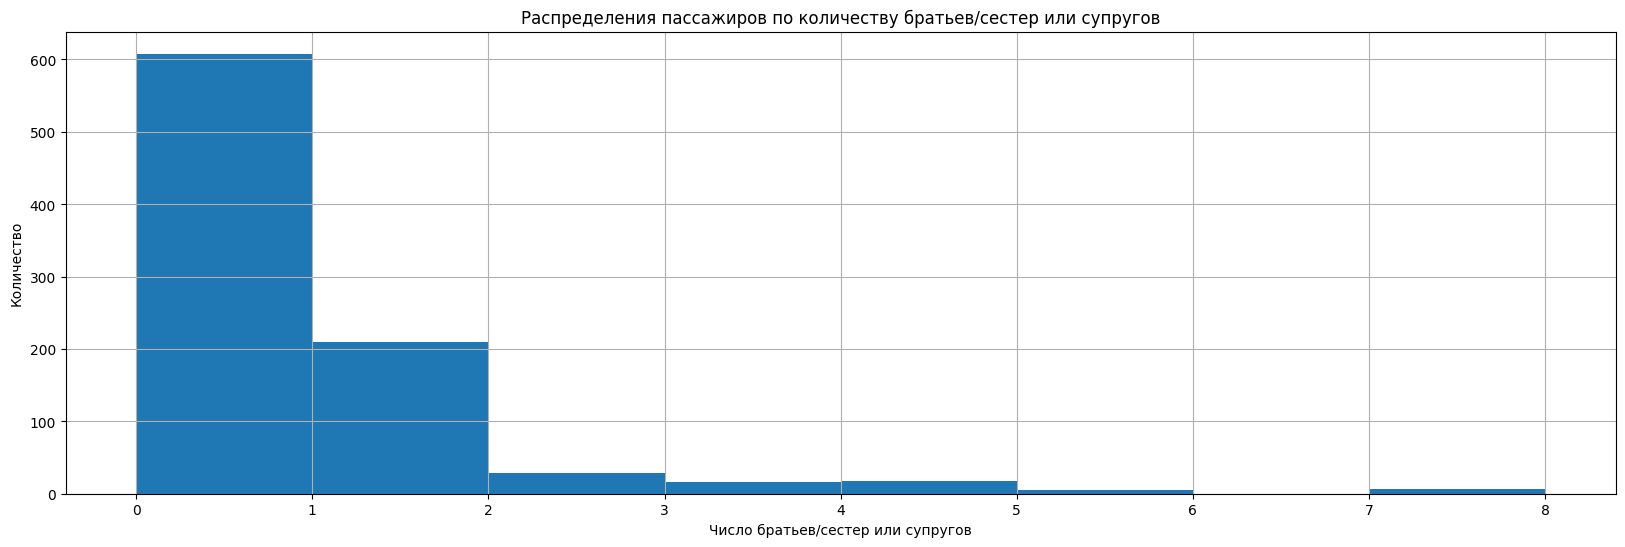

In [173]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов',
  'Число братьев/сестер или супругов')

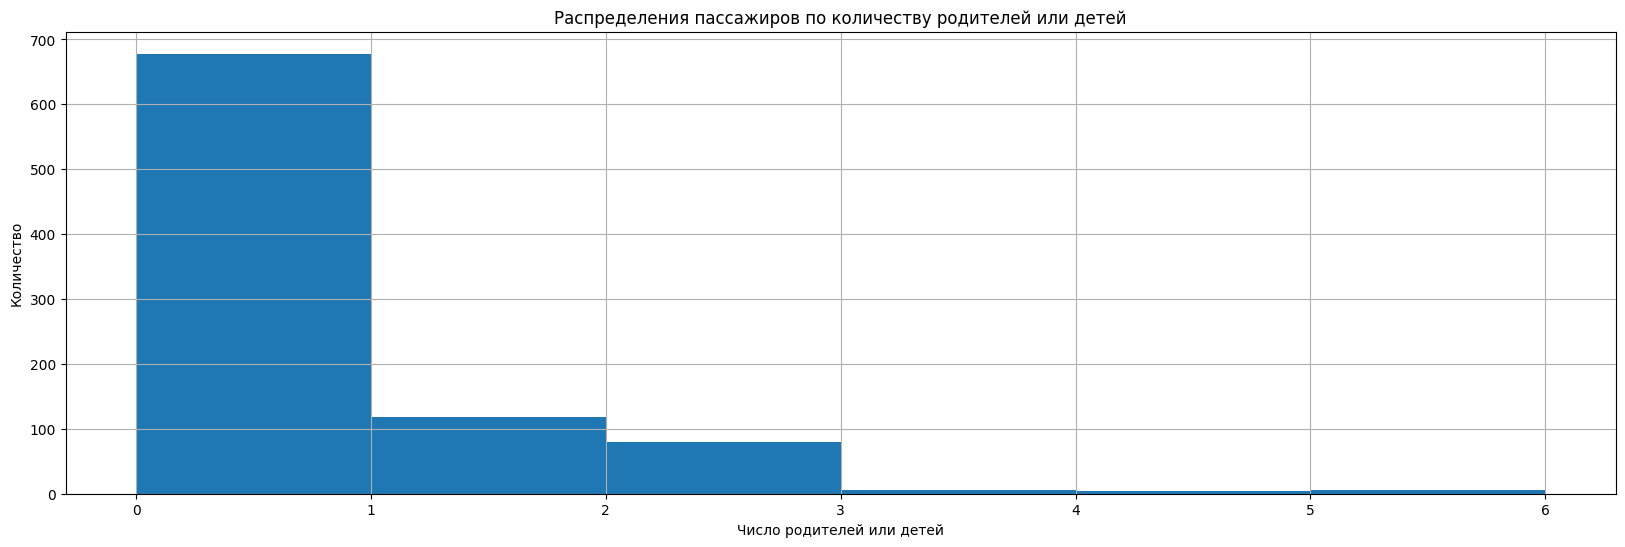

In [174]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей',
  'Число родителей или детей')

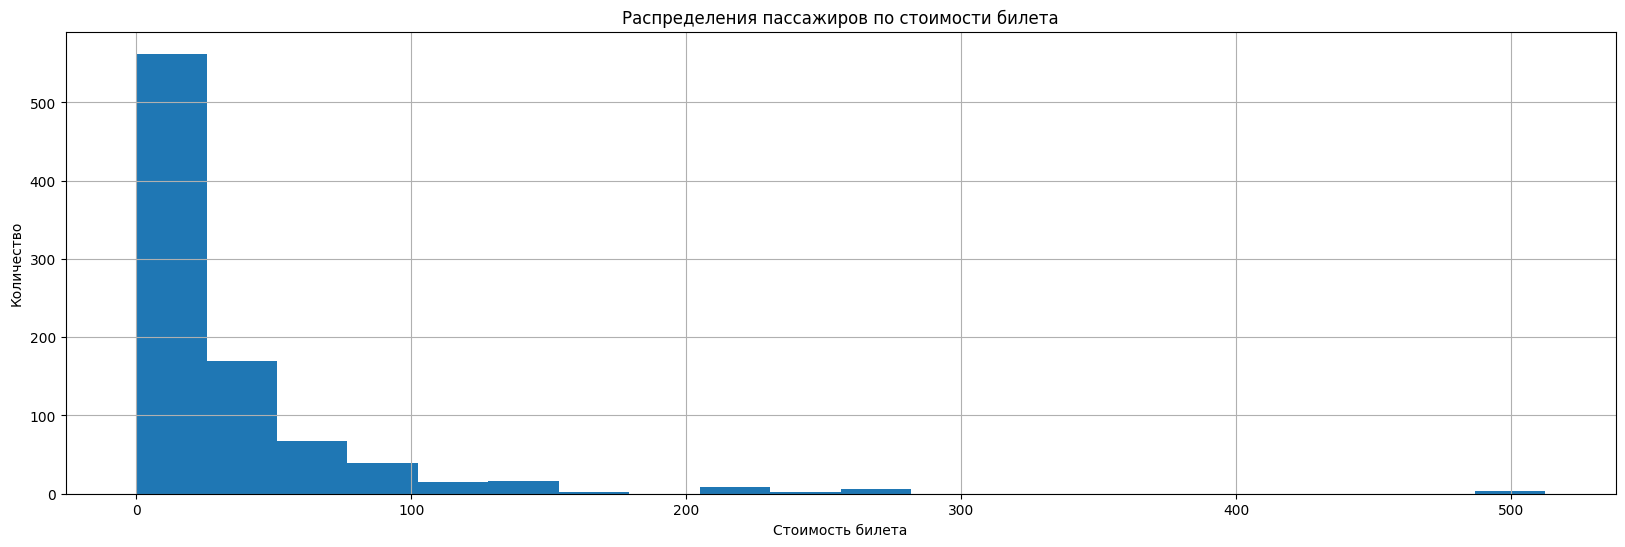

In [175]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета',
  'Стоимость билета', bins=20)

<Axes: ylabel='Frequency'>

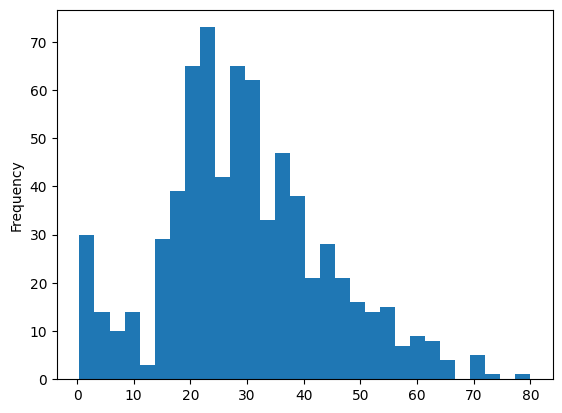

In [176]:
training_set['Age'].plot.hist(bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

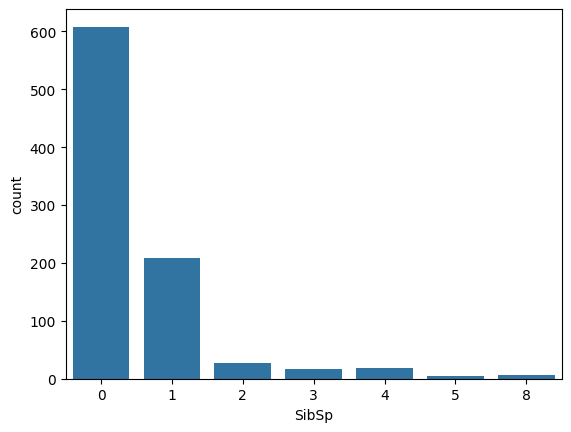

In [177]:
sns.countplot(x='SibSp', data=training_set)

In [178]:
training_set['Fare']

,Fare
0,7.2500
1,71.2833
2,7.9250
3,53.1000
4,8.0500
...,...
886,13.0000
887,30.0000
888,23.4500
889,30.0000


<Axes: >

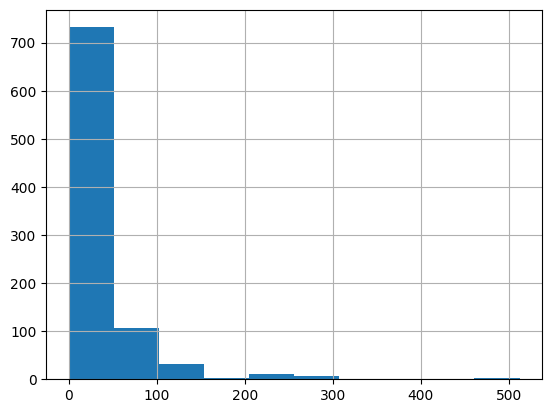

In [179]:
training_set['Fare'].hist()

<Axes: >

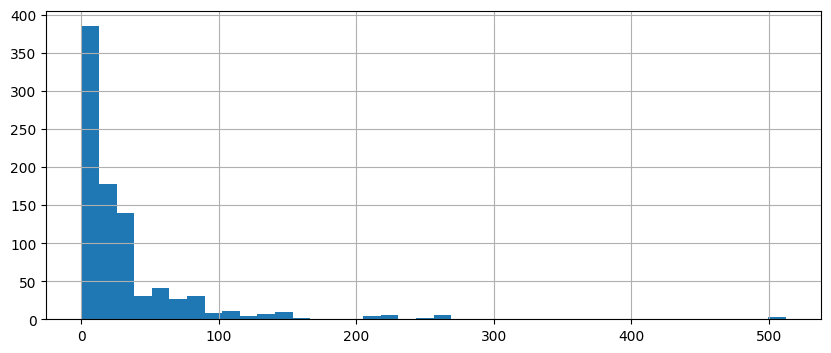

In [180]:
training_set['Fare'].hist(bins=40, figsize=(10,4))

<Axes: xlabel='Survived', ylabel='count'>

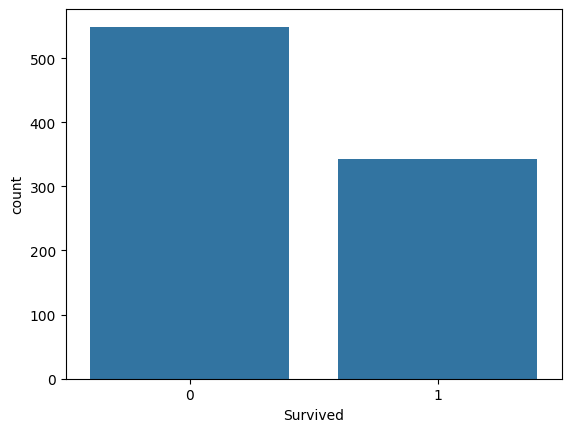

In [181]:
sns.countplot(x='Survived', data=training_set)

<Axes: xlabel='Survived', ylabel='count'>

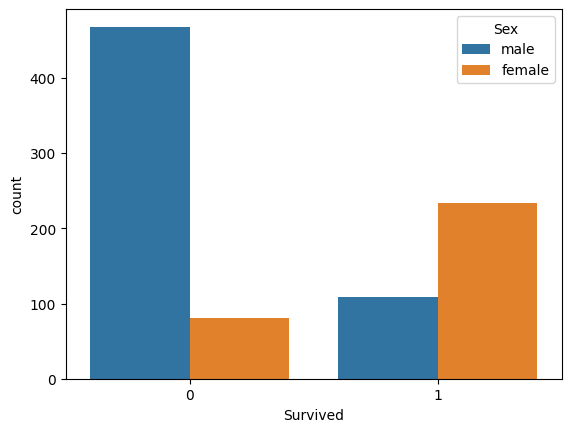

In [182]:
sns.countplot(x='Survived', data=training_set, hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

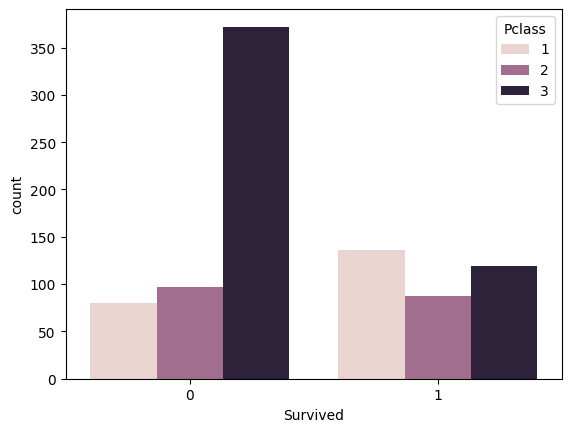

In [183]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

<Axes: xlabel='Pclass', ylabel='Age'>

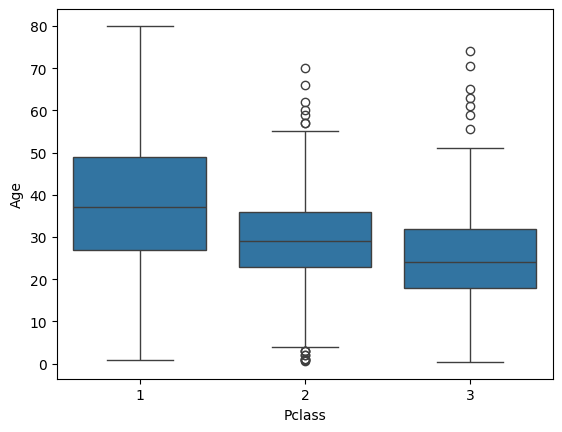

In [184]:
sns.boxplot(x='Pclass', y='Age', data=training_set)

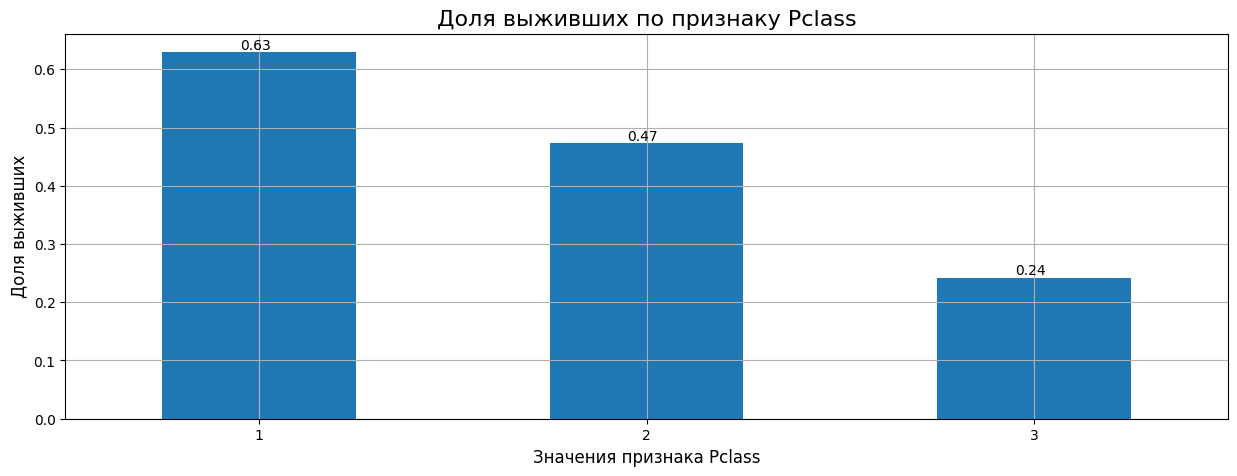

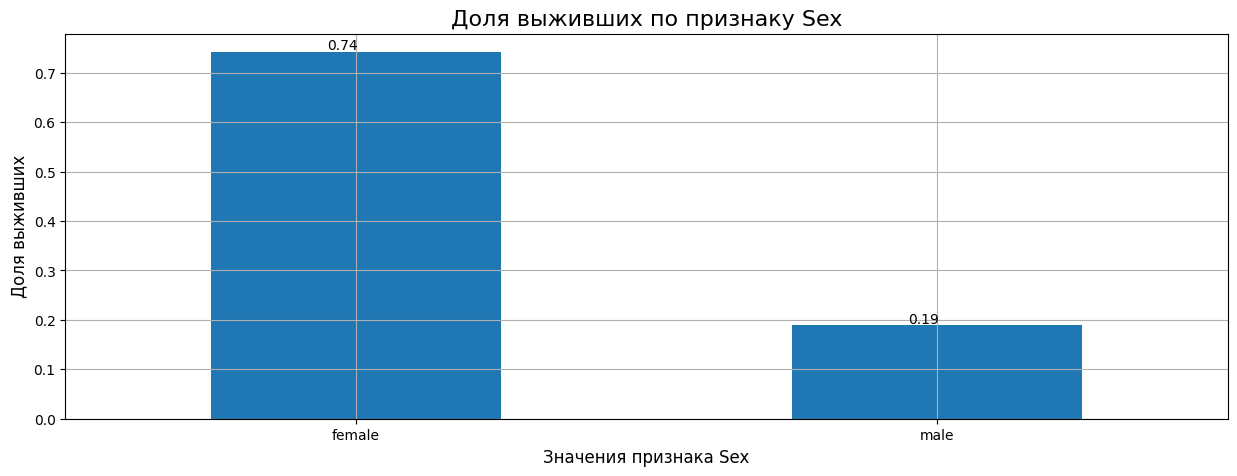

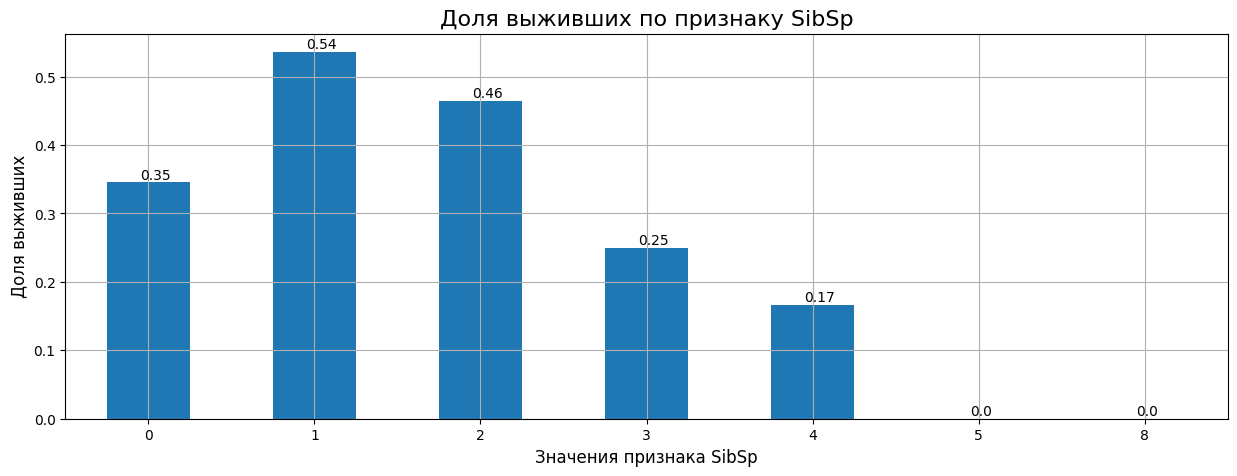

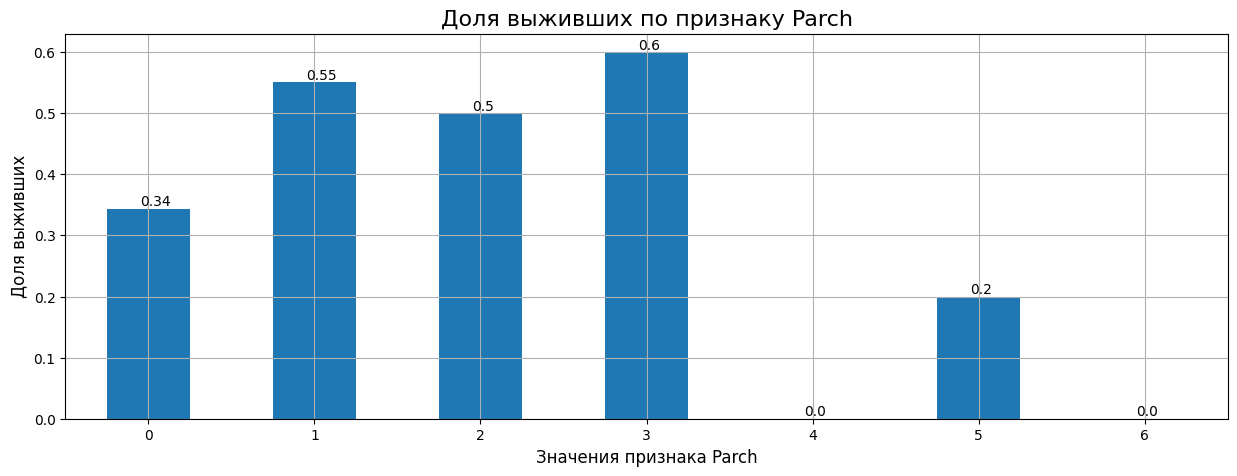

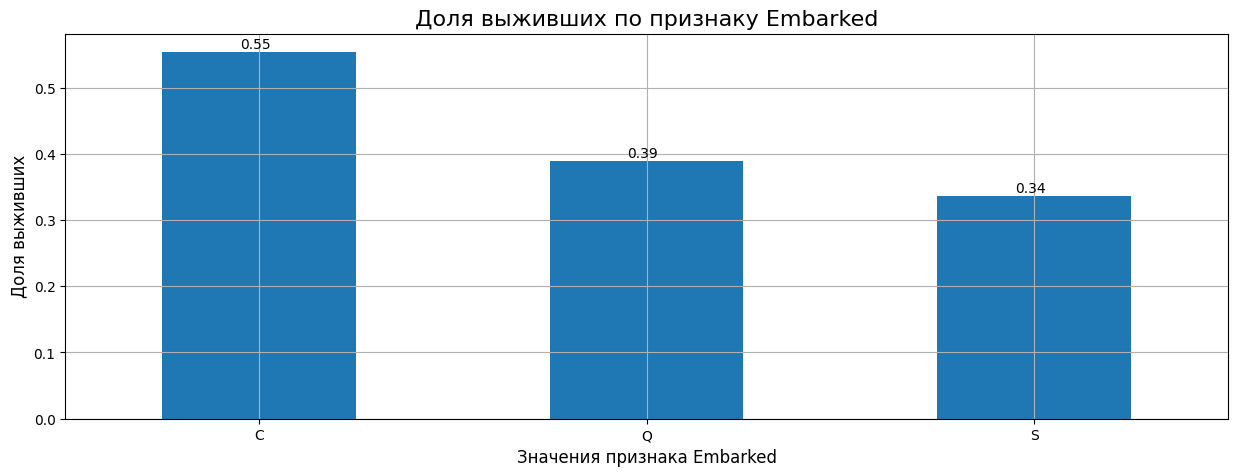

In [185]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')

    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})

    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))

    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax)
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

#### Исследование пропущенных значений

In [186]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [187]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [188]:
training_set.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


#### Исследование отсутствующих значений

In [189]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [190]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


<Axes: >

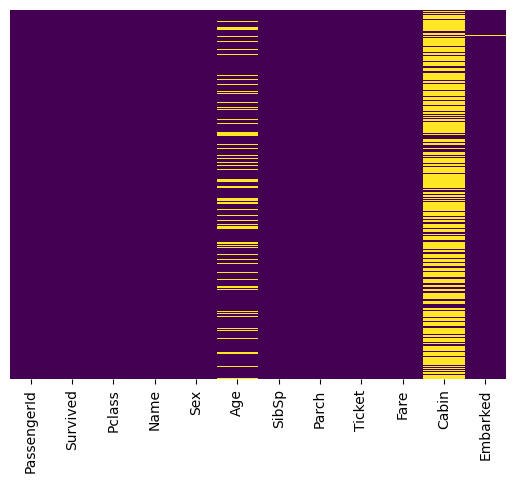

In [191]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [192]:
training_set.drop('Cabin', axis=1, inplace=True)

In [193]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

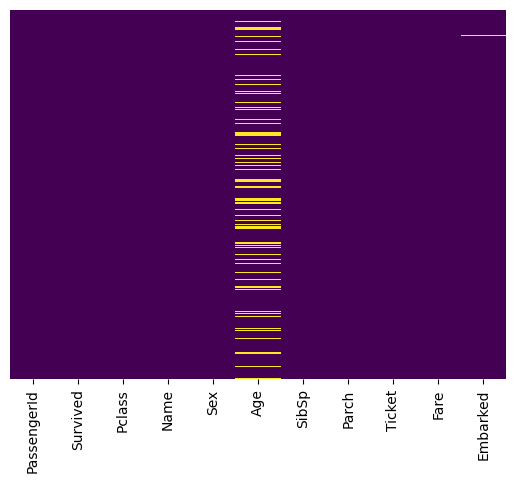

In [194]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [195]:
training_set.dropna(inplace=True)

<Axes: >

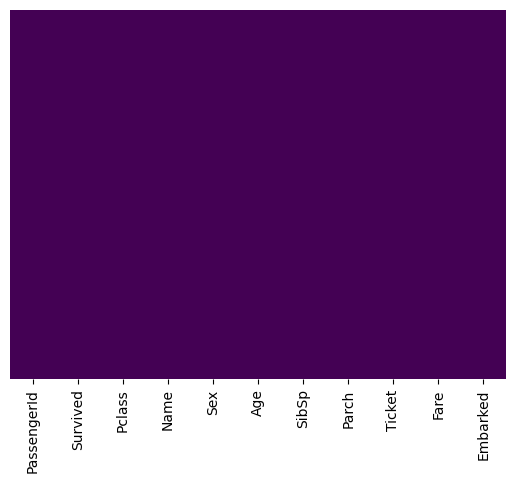

In [196]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

#### Преобразование категориальных признаков

In [197]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])


In [198]:
training_set['Sex'].unique()

array(['male', 'female'], dtype=object)

In [199]:
np.unique(cat_enc_le)

array([0, 1])

In [200]:
le.inverse_transform([0,1])

array(['female', 'male'], dtype=object)

In [201]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])  # Вызываем метод fit_transform, возвращает разреженную матрицу из библиотеки Scipy

In [202]:
training_set.shape

(712, 11)

In [203]:
cat_enc_ohe.shape

(712, 3)

In [204]:
pd.get_dummies(training_set['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
885,True,False
886,False,True
887,True,False
889,False,True


In [205]:
pd.get_dummies(training_set['Sex'], drop_first=True)

,male
0,True
1,False
2,False
3,False
4,True
...,...
885,False
886,True
887,False
889,True


In [206]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)

In [207]:
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)

In [208]:
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


In [209]:
training_set = pd.concat([training_set, sex, embark], axis=1)

In [210]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


In [211]:
training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [212]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


### Задания для самостоятельного выполнения

#### 1. Постройте по получившемуся набору данных простую модель машинного обучения и оцените ее эффективность.

In [213]:
y = training_set['Survived']
X = training_set.drop('Survived', axis=1)
base = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
base.fit(X_train, y_train)
y_pred = base.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.86      0.82        99
           1       0.80      0.71      0.75        79

    accuracy                           0.79       178
   macro avg       0.79      0.78      0.79       178
weighted avg       0.79      0.79      0.79       178



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### 2. Ответьте на следующие вопросы при помощи визуализации и численных данных по исходному набору данных:

#### 3.Какова доля выживших после крушения пассажиров? Какова доля мужчин и женщин среди выживших?

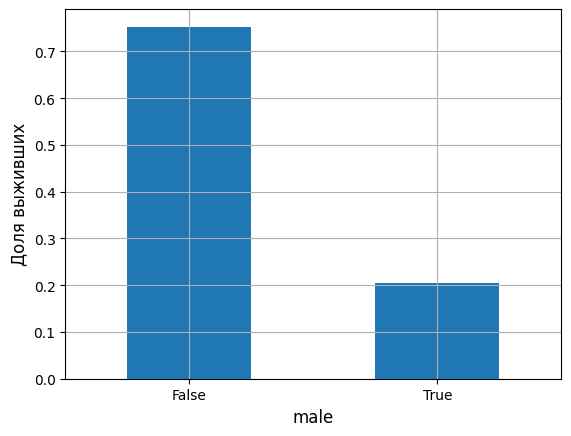

In [214]:
pivot = training_set.pivot_table(index=['male'], values='Survived', aggfunc='mean')
pivot.plot(kind='bar', rot=0, grid=True, legend=False)
plt.xlabel('male', fontdict={'size': 12})
plt.ylabel('Доля выживших', fontdict={'size': 12})
plt.show()

#### 4. Сколько пассажиров ехало в каждом классе? Кого было больше в самом многолюдном классе — мужчин или женщин?

In [215]:
training_set['Pclass'].value_counts()
most_crowded_class = training_set['Pclass'].value_counts().idxmax()
passengers_in_most_crowded_class = training_set[training_set['Pclass'] == most_crowded_class]
male_count = passengers_in_most_crowded_class['male'].sum()
female_count = len(passengers_in_most_crowded_class) - male_count
print(f'Most crowded class:{most_crowded_class}')
print(f'Male:{male_count}')
print(f'Female:{female_count}')

Most crowded class:3
Male:253
Female:102


#### 5. Все ли признаки несут в себе полезную информацию? Почему? Избавьтесь от ненужных столбцов.

In [216]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [217]:
training_set.drop(['S'], axis=1, inplace=True)

#### 6. Посчитайте, насколько сильно коррелируют друг с другом цена за билет и возраст пассажиров. Также проверьте наличие этой зависимости визуально (в этом вам поможет построение диаграммы рассеяния).

In [218]:
corr = training_set['Fare'].corr(training_set['Age'])
print(f'Корреляция между fare и age {corr}')

Корреляция между fare и age 0.09314251789411516


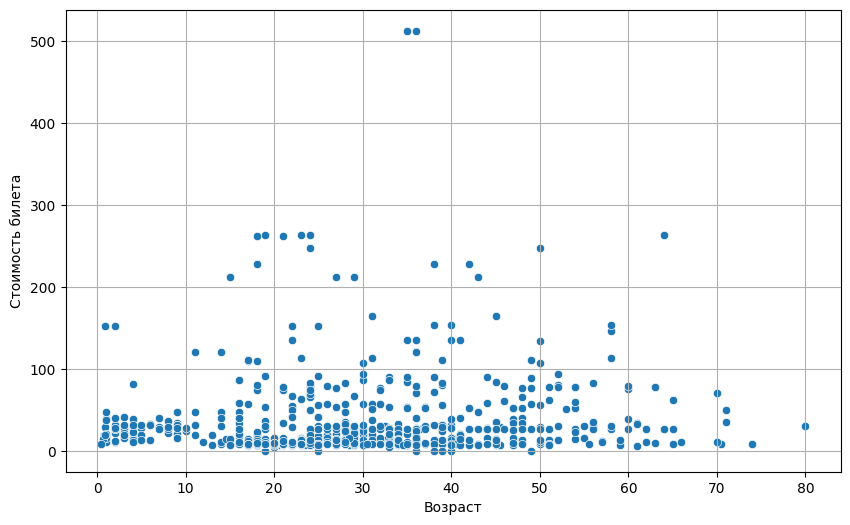

In [219]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Fare', data=training_set)
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.grid(True)
plt.show()

#### 7. Правда ли, что чаще выживали пассажиры с более дорогими билетами? А есть ли зависимость выживаемости от класса?

In [220]:
corr = training_set['Fare'].corr(training_set['Survived'])
print(f'Корреляция между fare и survived {corr}')

Корреляция между fare и survived 0.26609960047658043


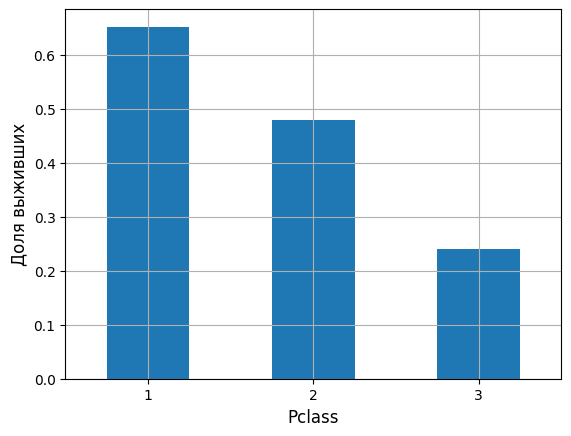

In [221]:
pivot = training_set.pivot_table(index=['Pclass'], values='Survived', aggfunc='mean')
pivot.plot(kind='bar', rot=0, grid=True, legend=False)
plt.xlabel('Pclass', fontdict={'size': 12})
plt.ylabel('Доля выживших', fontdict={'size': 12})
plt.show()

#### 8. Какова связь между стоимостью билета и портом отправления? Выведите минимальную, среднюю и максимальную сумму, которую заплатили пассажиры за проезд. Проделайте то же самое только для тех пассажиров, которые сели на корабль в Саутгемптоне.

In [222]:
corr = training_set['Q'].corr(training_set['Fare'])
print(f'Корреляция между fare и survived {corr}')

Корреляция между fare и survived -0.062346238112932655


In [223]:
fare_by_embarkation = training_set.groupby('Q')['Fare'].agg(['min', 'mean', 'max'])
print(fare_by_embarkation)

        min       mean       max
Q                               
False  0.00  35.234563  512.3292
True   6.75  18.265775   90.0000


#### 9. Выведите гистограммы, показывающие распределения стоимостей билетов в зависимости от места посадки.

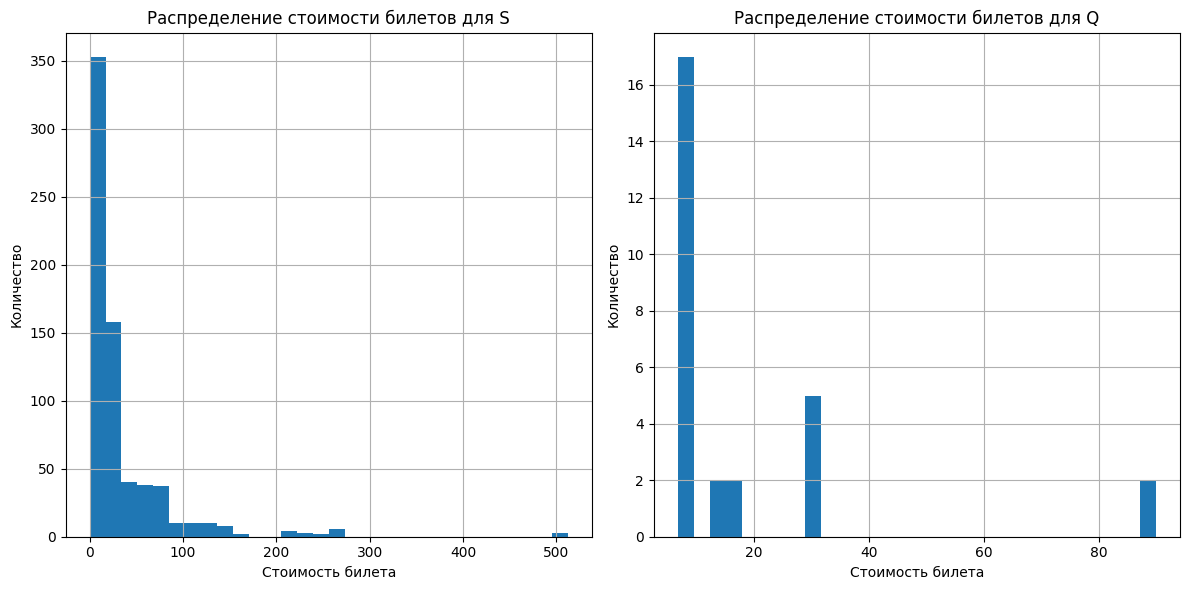

In [224]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
training_set[training_set['Q'] == False]['Fare'].hist(bins=30)
plt.title('Распределение стоимости билетов для S')
plt.xlabel('Стоимость билета')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
training_set[training_set['Q'] == True]['Fare'].hist(bins=30)
plt.title('Распределение стоимости билетов для Q')
plt.xlabel('Стоимость билета')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

#### 10. Оцените репрезентативность представленной выборки. Сколько всего было пассажиров Титаника? Сколько из них выжило? Какую долю составляет представленный набор данных от всей генеральной совокупности?

In [225]:
total_pass = len(training_set)
survived = training_set['Survived'].sum()

print(f'количество пассажиров в представленном наборе данных: {total_pass}')
print(f'Количество выживших в представленном наборе данных: {survived}')
print(f'Доля выживших в представленном наборе данных: {survived / total_pass}')
print(f'Доля от генеральной совокупности: ', total_pass / 2212)

количество пассажиров в представленном наборе данных: 712
Количество выживших в представленном наборе данных: 288
Доля выживших в представленном наборе данных: 0.4044943820224719
Доля от генеральной совокупности:  0.321880650994575


На борту «Титаника» находилось, по разным данным, от 2200 до 2224 человек (пассажиров и экипажа). В результате катастрофы выжило лишь около 700-712 человек, в то время как погибло более 1500

#### 11. Разделите выборку на тестовую и обучающую части при помощи train_test_split(). Изобразите на графиках распределение некоторых атрибутов и целевой переменной. Насколько однородно получившееся разбиение?

In [226]:
y = training_set['Survived']
X = training_set.drop('Survived', axis=1)
base = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


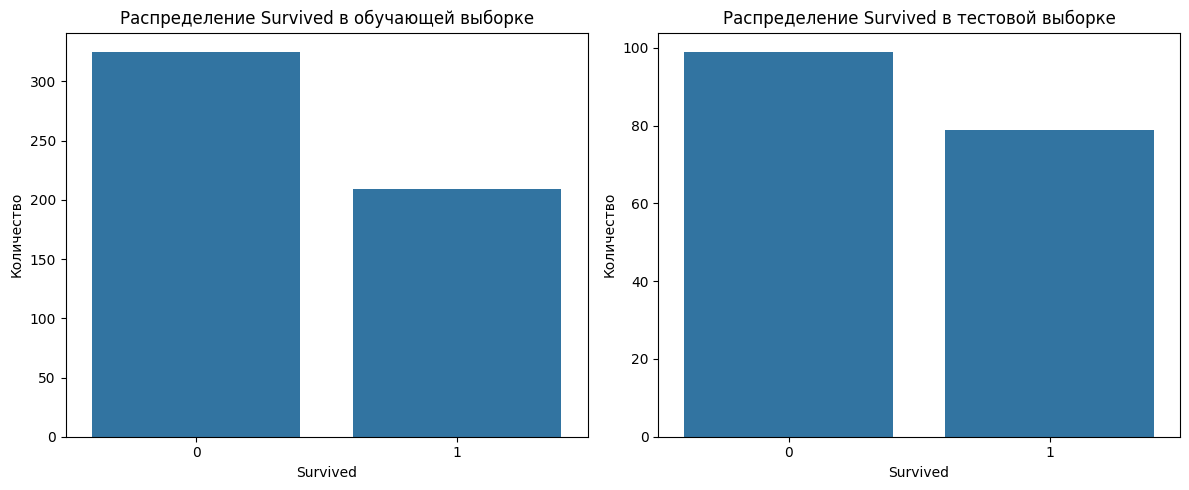

In [227]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_train)
plt.title('Распределение Survived в обучающей выборке')
plt.xlabel('Survived')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
sns.countplot(x=y_test)
plt.title('Распределение Survived в тестовой выборке')
plt.xlabel('Survived')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

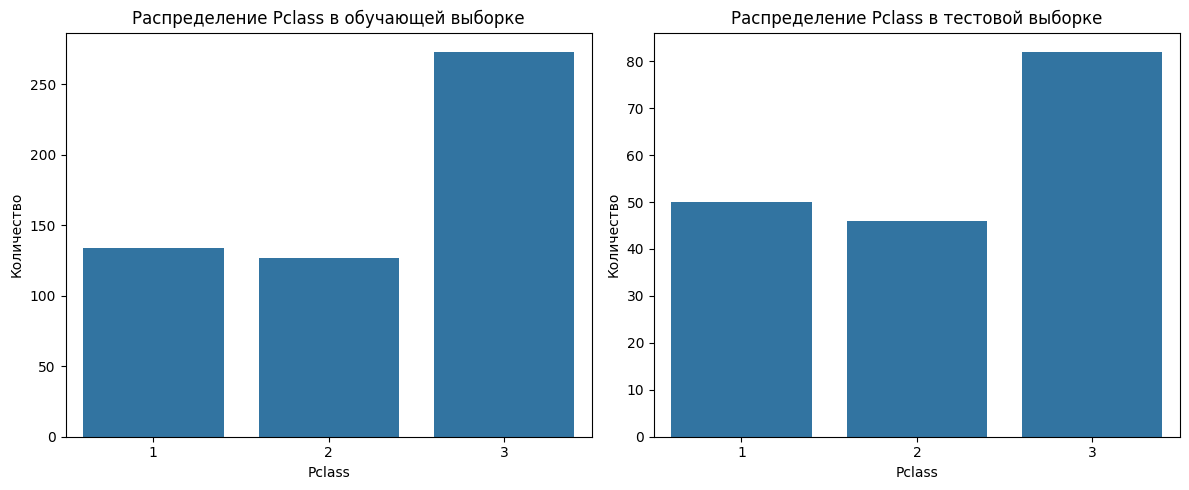

In [228]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=X_train['Pclass'])
plt.title('Распределение Pclass в обучающей выборке')
plt.xlabel('Pclass')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
sns.countplot(x=X_test['Pclass'])
plt.title('Распределение Pclass в тестовой выборке')
plt.xlabel('Pclass')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

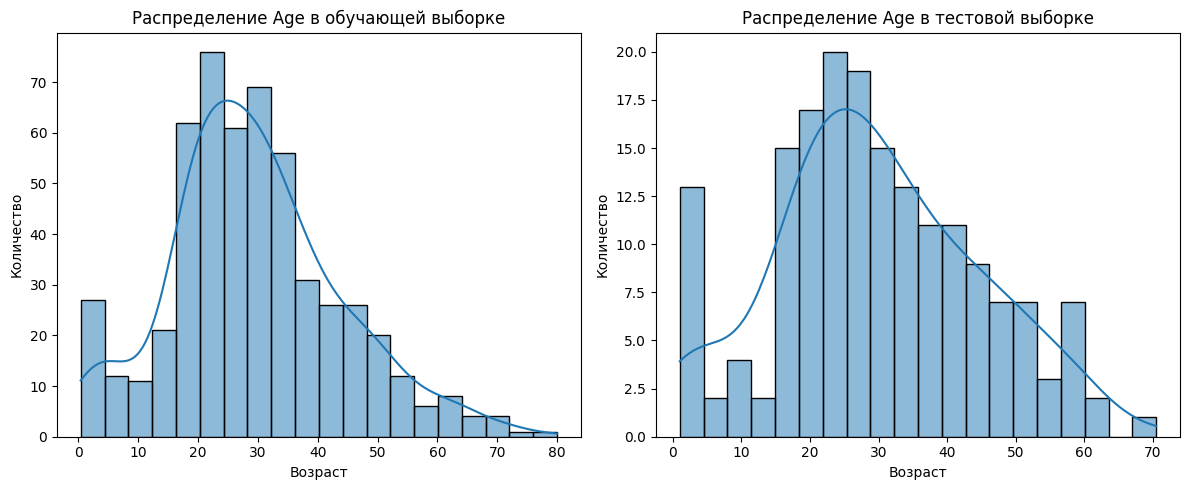

In [229]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(X_train['Age'], bins=20, kde=True)
plt.title('Распределение Age в обучающей выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество')

plt.subplot(1, 2, 2)
sns.histplot(X_test['Age'], bins=20, kde=True)
plt.title('Распределение Age в тестовой выборке')
plt.xlabel('Возраст')
plt.ylabel('Количество')

plt.tight_layout()
plt.show()

#### 12. Сбалансируйте классы в исходном датасете двумя способами:

#### 13. Удалите лишние объекты мажоритарного класса (выбранные случайно)

In [230]:
df_maj = training_set[training_set.Survived == 0]
df_min = training_set[training_set.Survived == 1]
df_maj_sampled = resample(df_maj,
                            replace=False,
                            n_samples=len(df_min),
                            random_state=42)
df_downsampled = pd.concat([df_maj_sampled, df_min])
print('Распределение классов после удаления объектов мажоритарного класса:')
print(df_downsampled.Survived.value_counts())


Распределение классов после удаления объектов мажоритарного класса:
Survived
0    288
1    288
Name: count, dtype: int64


#### 14. Добавьте в выборку дубликаты миноритарного класса.

In [231]:

df_maj = training_set[training_set.Survived == 0]
df_min = training_set[training_set.Survived == 1]

df_min_upsampled = resample(df_min,
                                 replace=True,
                                 n_samples=len(df_maj),
                                 random_state=42)

df_upsampled = pd.concat([df_maj, df_min_upsampled])


print('Распределение классов после добавления дубликатов миноритарного класса:')
print(df_upsampled.Survived.value_counts())


Распределение классов после добавления дубликатов миноритарного класса:
Survived
0    424
1    424
Name: count, dtype: int64


#### 15. Проведите исследование эффективности простой модели классификации до и после данных преобразований.

In [239]:
y = training_set['Survived']
X = training_set.drop('Survived', axis=1)
base = LogisticRegression(max_iter=10000)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
base.fit(X_train, y_train)
y_pred = base.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83        99
           1       0.82      0.71      0.76        79

    accuracy                           0.80       178
   macro avg       0.81      0.79      0.80       178
weighted avg       0.81      0.80      0.80       178



In [240]:
y = df_downsampled['Survived']
X = df_downsampled.drop('Survived', axis=1)
base_down = LogisticRegression(max_iter=10000)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
base_down.fit(X_train, y_train)
y_pred = base_down.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81        80
           1       0.76      0.78      0.77        64

    accuracy                           0.79       144
   macro avg       0.79      0.79      0.79       144
weighted avg       0.79      0.79      0.79       144



In [241]:
y = df_upsampled['Survived']
X = df_upsampled.drop('Survived', axis=1)
base_down = LogisticRegression(max_iter=10000)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
base_down.fit(X_train, y_train)
y_pred = base_down.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.87      0.79        98
           1       0.86      0.73      0.79       114

    accuracy                           0.79       212
   macro avg       0.80      0.80      0.79       212
weighted avg       0.80      0.79      0.79       212



#### 16. Постройте корреляционную матрицу признаков после преобразования данных. Сделайте вывод о наличии либо отсутствии мультиколлинеарности признаков.

<Axes: >

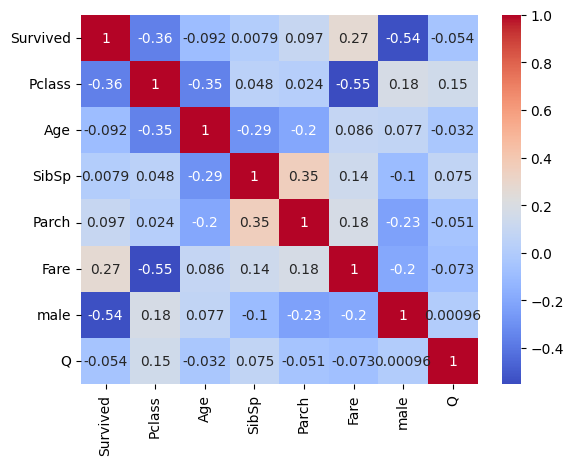

In [242]:
sns.heatmap(df_downsampled.corr(), annot=True, cmap='coolwarm')

#### 17. Проведите группировку данных по значению возраста. Введите новый признак "возрастная категория", значениями которой будут "ребенок", "взрослый", "старик". Проведите анализ эффективности данного признака.

In [245]:
def get_age_category(age):
    if age < 18:
        return 'ребенок'
    elif age >= 60:
        return 'старик'
    else:
        return 'взрослый'

training_set['AgeCategory'] = training_set['Age'].apply(get_age_category)

display(training_set.head())

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,AgeCategory
0,0,3,22.0,1,0,7.2500,True,False,взрослый
1,1,1,38.0,1,0,71.2833,False,False,взрослый
2,1,3,26.0,0,0,7.9250,False,False,взрослый
3,1,1,35.0,1,0,53.1000,False,False,взрослый
4,0,3,35.0,0,0,8.0500,True,False,взрослый


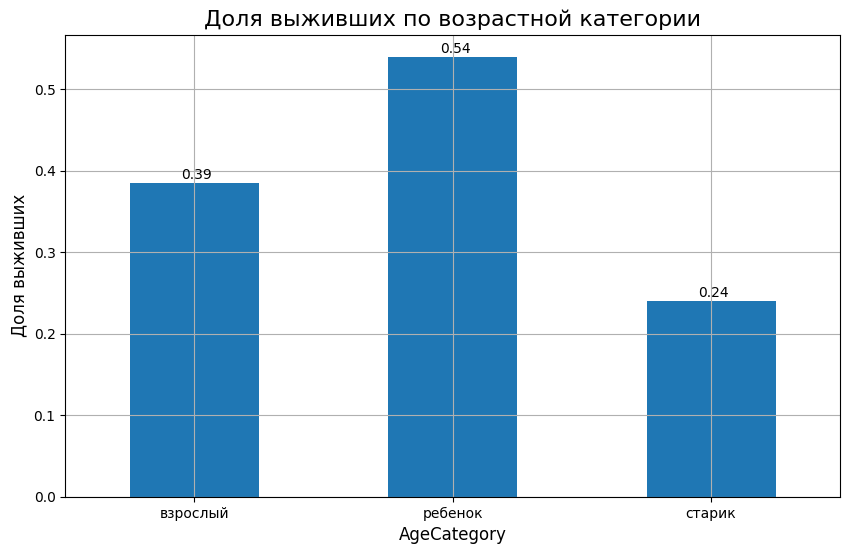

In [246]:
pivot_age_category = training_set.pivot_table(index='AgeCategory', values='Survived', aggfunc='mean')

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('Доля выживших по возрастной категории', fontdict={'size': 16})
ax.set_ylabel('Доля выживших', fontdict={'size': 12})
ax.set_xlabel('Возрастная категория', fontdict={'size': 12})

for cnt in range(pivot_age_category.shape[0]):
    value = pivot_age_category.iloc[cnt].values[0]
    ax.text(cnt - .05, value + .005, round(value, 2))

pivot_age_category.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax)
plt.show()


Из графика видно, что дети имели значительно более высокую долю выживших по сравнению с взрослыми и стариками. Этот признак может быть  полезен для модели прогнозирования выживаемости.